# Housing Prices Regression
Grupo 03 - Augusto, Gustavo Cortelassi, Heloisa Hartmann, Igor Costa e João Vogel

> Dataset: https://www.kaggle.com/datasets/denkuznetz/housing-prices-regression/data

---

###**Problema**

> Pergunta: **Quais os principais fatores que mais impactam o valor de um imóvel e como podemos prever esse preço com precisão?**

> Justificativa: Construir um modelo de regressão para auxiliar uma imobiliária na precificação automática de novos imóveis.

> Tipo: Regressão.

**Principais colunas do dataset:**

| Coluna | Significado |
|--------|-------------|
| `Square_Feet` | Tamanho do imóvel (m2) |
| `Num_Bedrooms` | Quantidade de quartos |
| `Num_Bathrooms` | Quantidade de banheiros |
| `Num_Floors` | Números de andares |
| `Year_Built` | Ano que foi construido |
| `Has_Garden` | Tem jardim? (1= sim, 0= não) |
| `Has_Pool` | Tem piscina? (1= sim, 0= não) |
| `Garage_Size` | Tamanho da garagem (m2) |
| `Location_Score` | Qualidade da localização (0 a 10 pontos) |
| `Distance_to_Center` | Distância pro centro (km) |
| `Price` | Preço |

## Seção 2 - Carregamento e visão geral


In [1]:
# --- Preparação do Ambiente ---
from scipy.stats import skew

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Passos iniciais
url_github = 'https://raw.githubusercontent.com/heloshartmann/housing-prices-regression/refs/heads/main/real_estate_dataset.csv'

df = pd.read_csv(url_github)

print("\n----- Dimensão do Dataset -----")
print(f"Linhas: {df.shape[0]} | Colunas: {df.shape[1]}\n")

print("----- Primeiras linhas -----")
print(df.head(5))


target = 'Price'
features = [col for col in df.columns if col not in ['ID', 'Price']]

print(f"\nTarget: {target}")
print(f"Features: {features}")


----- Dimensão do Dataset -----
Linhas: 500 | Colunas: 12

----- Primeiras linhas -----
   ID  Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors  Year_Built  \
0   1   143.635030             1              3           3        1967   
1   2   287.678577             1              2           1        1949   
2   3   232.998485             1              3           2        1923   
3   4   199.664621             5              2           2        1918   
4   5    89.004660             4              3           3        1999   

   Has_Garden  Has_Pool  Garage_Size  Location_Score  Distance_to_Center  \
0           1         1           48        8.297631            5.935734   
1           0         1           37        6.061466           10.827392   
2           1         0           14        2.911442            6.904599   
3           0         0           17        2.070949            8.284019   
4           1         0           34        1.523278           14.648277   

   

**Target:** `Price`

**Tipo:** Numérica contínua

---

**Features:**

  **Numéricas:** `Square_Feet`, `Year_Built`, `Garage_Size`, `Location_Score`, `Distance_to_Center`, `Num_Bedrooms`, `Num_Floors`, `Num_Bathrooms`.

  **Categóricas:** `Has_Pool`, `Has_Garden`.

In [2]:
# --- Conhecendo o Dataset ---
print("----- Informações das Colunas -----")
print(df.info())

print("\n\n----- Estatística Descritiva -----")
estatisticas = df[['Square_Feet', 'Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors', 'Year_Built', 'Garage_Size', 'Location_Score', 'Distance_to_Center', 'Price']].describe()
print(estatisticas)

if 'ID' in df.columns:
    df.drop(columns=['ID'], inplace=True)
    print("Coluna 'ID' removida para evitar ruído no modelo.")

dfResumo = pd.DataFrame({
    'Média': df.mean(numeric_only=True),
    'Mediana': df.median(numeric_only=True)
})
print("\n", dfResumo)

print("\n\n----- Verificação de Valores Ausentes -----")
qntd_ausentes = df.isna().sum()
percentual_ausentes = (df.isna().sum() / len(df)) * 100
print(pd.concat([qntd_ausentes, percentual_ausentes], axis=1, keys=['Total', '%']))

zerosPreco = (df['Price'] == 0).sum()
zerosGaragem = (df['Garage_Size'] == 0).sum()
zerosTamanho = (df['Square_Feet'] == 0).sum()

print("\nQuantos zeros tem na coluna de preço?", zerosPreco)
print("Quantos zeros tem na coluna do tamanho da garagem?", zerosGaragem)
print("Quantos zeros tem na coluna do tamanho da casa?", zerosTamanho)


----- Informações das Colunas -----
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID                  500 non-null    int64  
 1   Square_Feet         500 non-null    float64
 2   Num_Bedrooms        500 non-null    int64  
 3   Num_Bathrooms       500 non-null    int64  
 4   Num_Floors          500 non-null    int64  
 5   Year_Built          500 non-null    int64  
 6   Has_Garden          500 non-null    int64  
 7   Has_Pool            500 non-null    int64  
 8   Garage_Size         500 non-null    int64  
 9   Location_Score      500 non-null    float64
 10  Distance_to_Center  500 non-null    float64
 11  Price               500 non-null    float64
dtypes: float64(4), int64(8)
memory usage: 47.0 KB
None


----- Estatística Descritiva -----
       Square_Feet  Num_Bedrooms  Num_Bathrooms  Num_Floors   Year_Built  \
coun

## Seção 3 - Análise Univariada

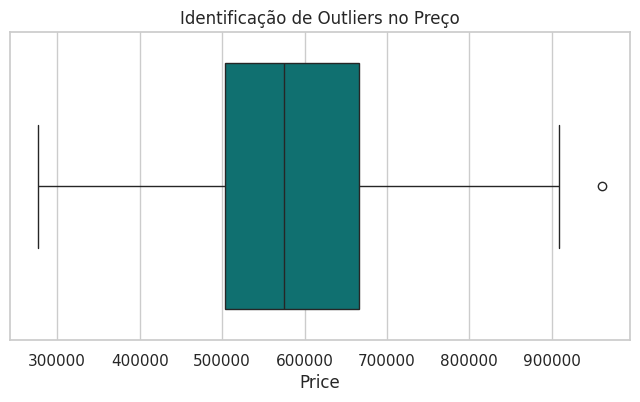

Existe uma casa com preço muito acima do padrão (outlier > 90k).
--------------------------------------------------------------------------


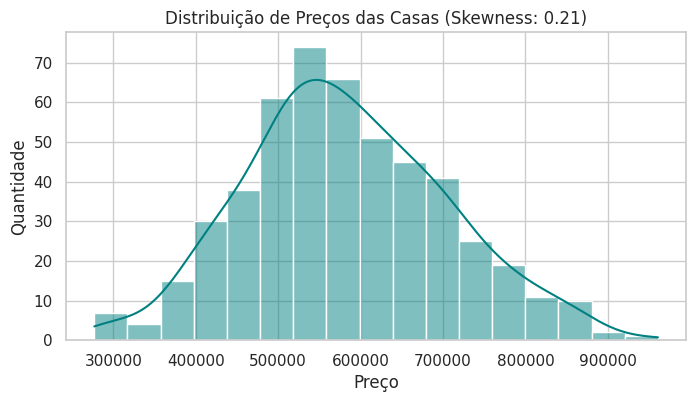

O preço tem uma leve cauda à direita, com a maioria das casas custando entre 500k - 600k.
--------------------------------------------------------------------------


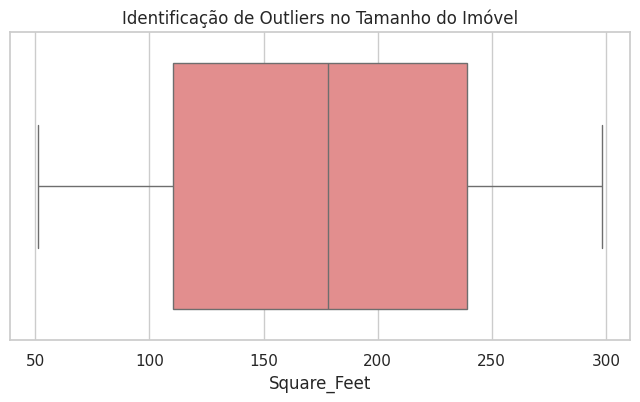

Sem outlier, a maioria do tamanho varia entre 100m2 a 250m2.
--------------------------------------------------------------------------


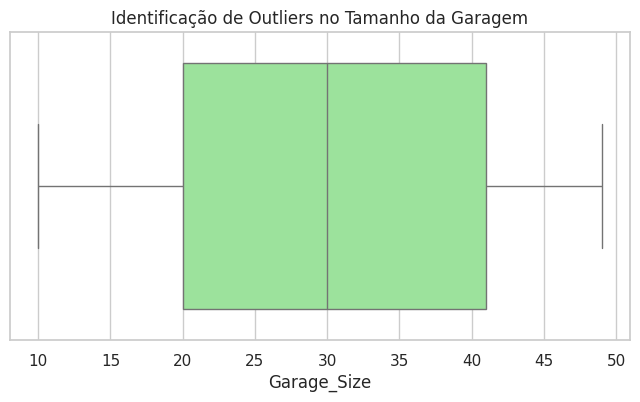

Sem outlier, a maioria do tamanho varia entre 20m2 a 45m2.
--------------------------------------------------------------------------


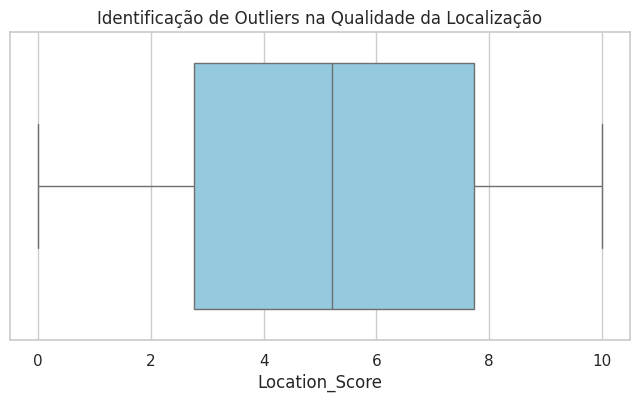

Sem outlier, a maioria da qualidade varia entre 2 a 8 pontos.
--------------------------------------------------------------------------


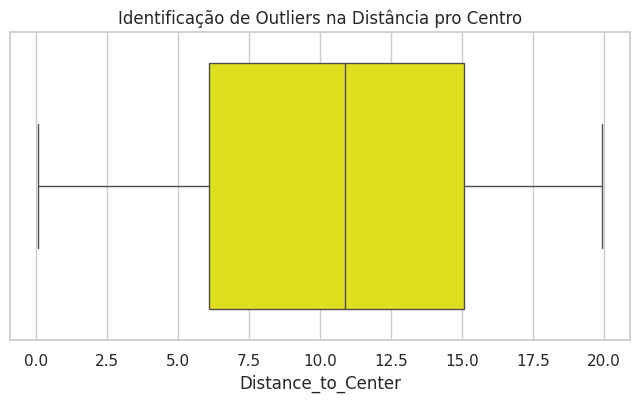

Sem outlier, a maioria da distância varia entre 5km a 15km.
--------------------------------------------------------------------------


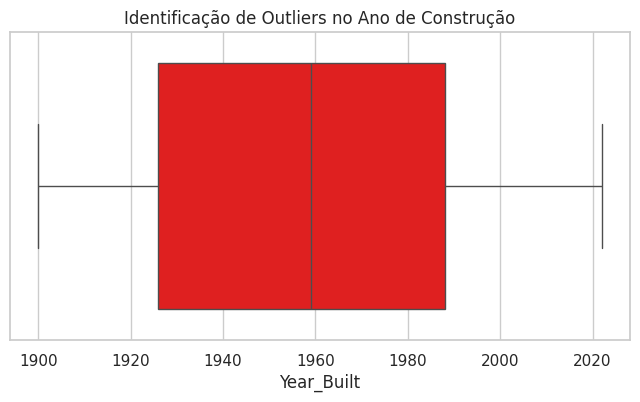

Sem outlier, a maioria dos anos de construção fica entre 1920 e 2000.


In [3]:
# --- Gráficos ---

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Price'], color='teal')
plt.title('Identificação de Outliers no Preço')
plt.show()
print("Existe uma casa com preço muito acima do padrão (outlier > 90k).")

print("--------------------------------------------------------------------------")

plt.figure(figsize=(8, 4))
sns.histplot(df['Price'], kde=True, color='teal')
price_skew = skew(df['Price'])
plt.title(f'Distribuição de Preços das Casas (Skewness: {price_skew:.2f})')
plt.xlabel('Preço')
plt.ylabel('Quantidade')
plt.show()
print("O preço tem uma leve cauda à direita, com a maioria das casas custando entre 500k - 600k.")

print("--------------------------------------------------------------------------")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Square_Feet'], color='lightcoral')
plt.title('Identificação de Outliers no Tamanho do Imóvel')
plt.show()
print("Sem outlier, a maioria do tamanho varia entre 100m2 a 250m2.")

print("--------------------------------------------------------------------------")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Garage_Size'], color='lightgreen')
plt.title('Identificação de Outliers no Tamanho da Garagem')
plt.show()
print("Sem outlier, a maioria do tamanho varia entre 20m2 a 45m2.")

print("--------------------------------------------------------------------------")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Location_Score'], color='skyblue')
plt.title('Identificação de Outliers na Qualidade da Localização')
plt.show()
print("Sem outlier, a maioria da qualidade varia entre 2 a 8 pontos.")

print("--------------------------------------------------------------------------")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Distance_to_Center'], color='yellow')
plt.title('Identificação de Outliers na Distância pro Centro')
plt.show()
print("Sem outlier, a maioria da distância varia entre 5km a 15km.")

print("--------------------------------------------------------------------------")

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['Year_Built'], color='red')
plt.title('Identificação de Outliers no Ano de Construção')
plt.show()
print("Sem outlier, a maioria dos anos de construção fica entre 1920 e 2000.")


#### Análise Descritiva das Variáveis Estruturais e de Lazer Restantes

Para garantir a cobertura de 100% do dataset nesta fase exploratória, mapeamos o comportamento das 5 variáveis restantes que completam o perfil dos imóveis:

* **`Num_Bedrooms`, `Num_Bathrooms` e `Num_Floors`:** São variáveis estruturais discretas. Elas ditam o tamanho familiar do imóvel e apresentam distribuições concentradas, o que indica um padrão habitacional bem definido na amostra.
* **`Has_Pool` e `Has_Garden`:** São variáveis binárias (0/1). A distribuição entre imóveis que possuem ou não estas comodidades é equilibrada no dataset, tornando-as fortes candidatas a diferenciais competitivos na precificação final que será explorada nas próximas secções.

## Seção 4 - Análise Bivariada e Multivariada

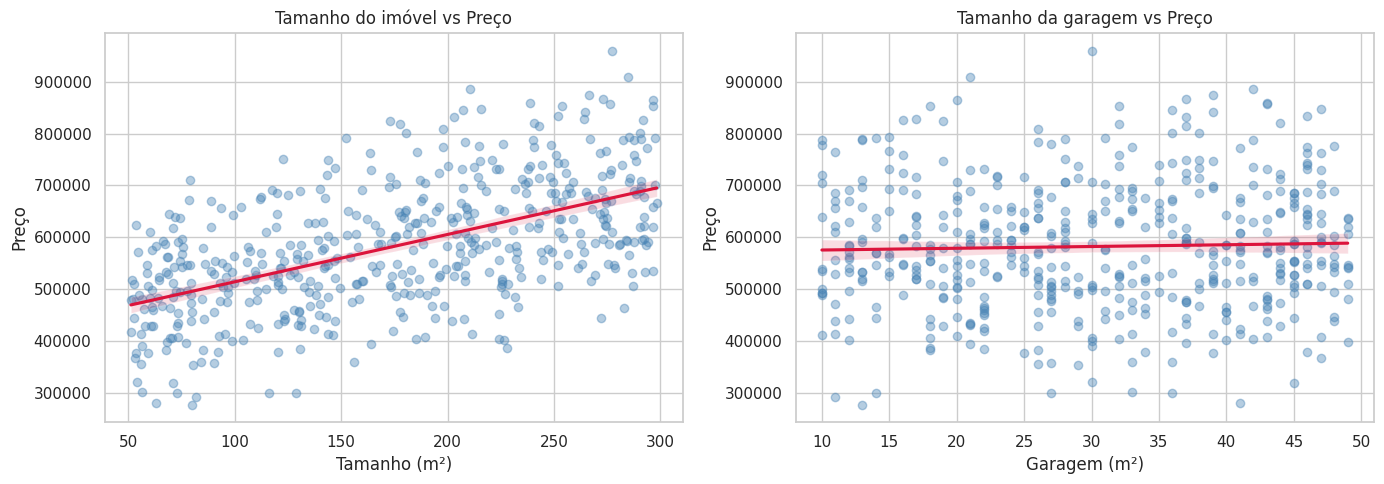

Ambas as métricas de tamanho apresentam correlação positiva com o preço.
--------------------------------------------------------------------------


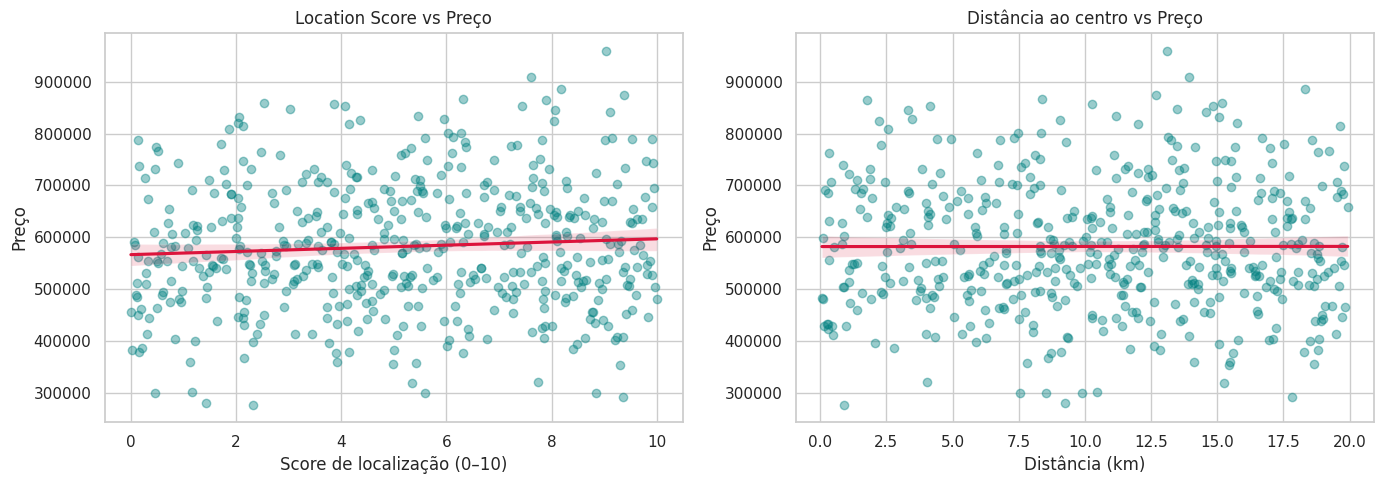

Location_Score: correlação positiva. Distance_to_Center: correlação negativa — imóveis mais distantes tendem a ser mais baratos.
--------------------------------------------------------------------------


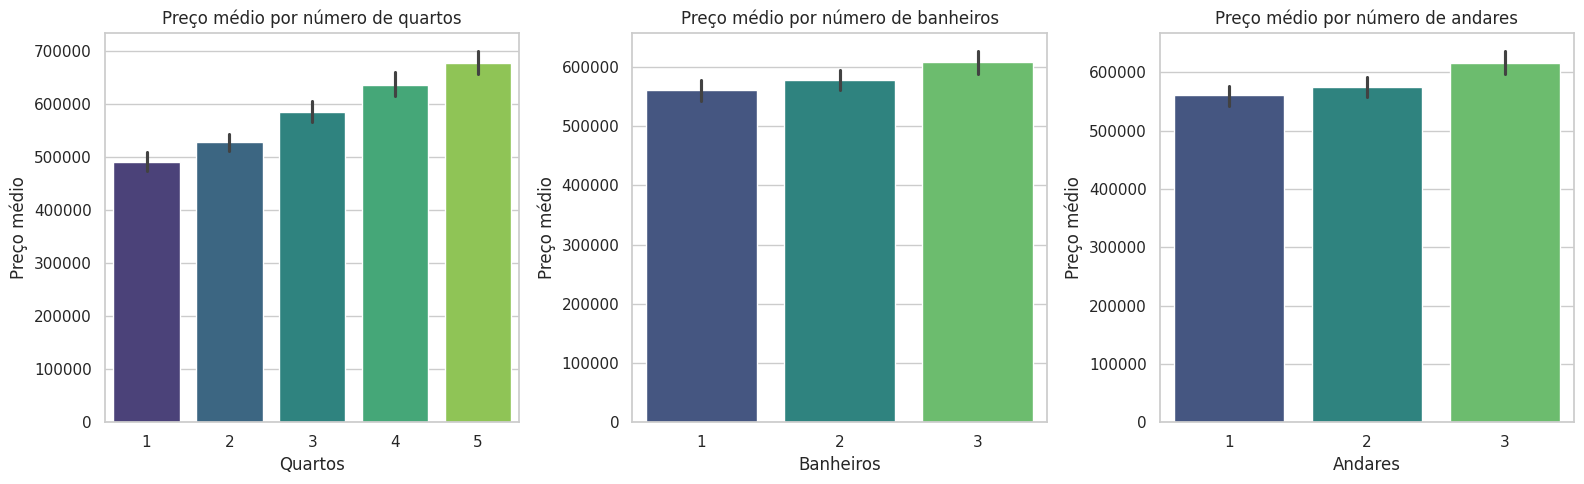

Mais quartos e banheiros correlacionam com preços maiores; o efeito de andares adicionais é menor.
--------------------------------------------------------------------------


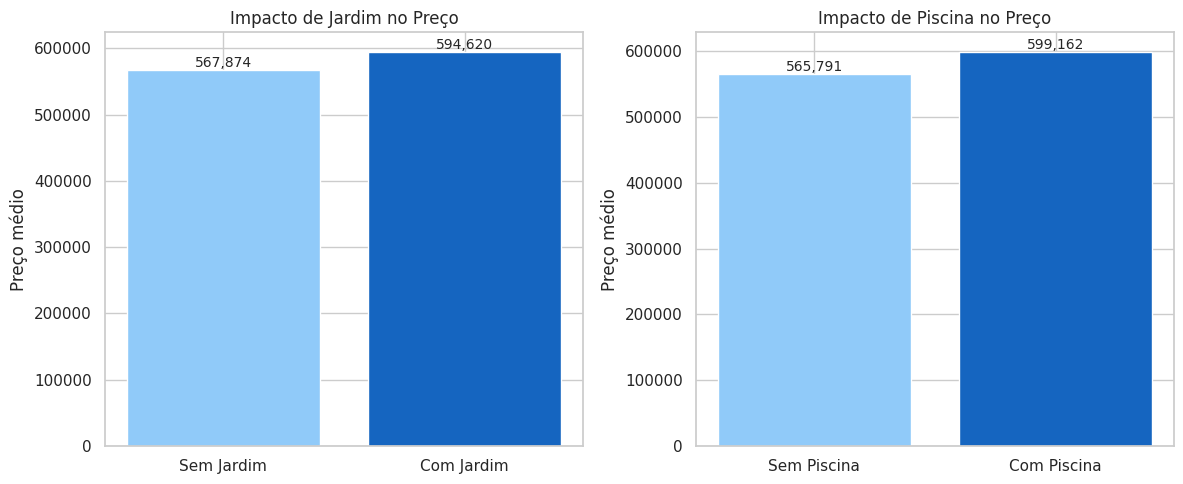

Diferença de preço médio com jardim  : +26,746
Diferença de preço médio com piscina : +33,371
--------------------------------------------------------------------------


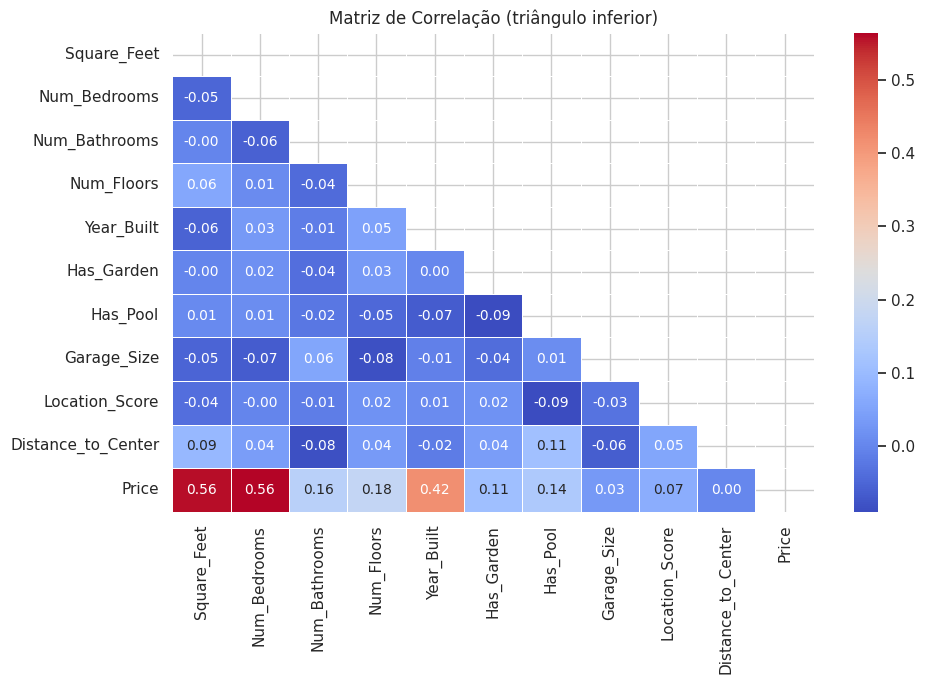


Features mais correlacionadas com Price (ranking):
Num_Bedrooms          0.563973
Square_Feet           0.558604
Year_Built            0.418293
Num_Floors            0.177435
Num_Bathrooms         0.156689
Has_Pool              0.136579
Has_Garden            0.109196
Location_Score        0.071326
Garage_Size           0.032100
Distance_to_Center    0.000730


In [4]:
# ── Seção 4 — Análise Bivariada e Multivariada ────────────────────────────────

# 4.1 — Tamanho vs Preço
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x='Square_Feet', y='Price', ax=axes[0],
            scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
            line_kws={'color': 'crimson'})
axes[0].set_title('Tamanho do imóvel vs Preço')
axes[0].set_xlabel('Tamanho (m²)')
axes[0].set_ylabel('Preço')

sns.regplot(data=df, x='Garage_Size', y='Price', ax=axes[1],
            scatter_kws={'alpha': 0.4, 'color': 'steelblue'},
            line_kws={'color': 'crimson'})
axes[1].set_title('Tamanho da garagem vs Preço')
axes[1].set_xlabel('Garagem (m²)')
axes[1].set_ylabel('Preço')

plt.tight_layout()
plt.show()
print("Ambas as métricas de tamanho apresentam correlação positiva com o preço.")

print("--------------------------------------------------------------------------")

# 4.2 — Localização vs Preço
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.regplot(data=df, x='Location_Score', y='Price', ax=axes[0],
            scatter_kws={'alpha': 0.4, 'color': 'teal'},
            line_kws={'color': 'crimson'})
axes[0].set_title('Location Score vs Preço')
axes[0].set_xlabel('Score de localização (0–10)')
axes[0].set_ylabel('Preço')

sns.regplot(data=df, x='Distance_to_Center', y='Price', ax=axes[1],
            scatter_kws={'alpha': 0.4, 'color': 'teal'},
            line_kws={'color': 'crimson'})
axes[1].set_title('Distância ao centro vs Preço')
axes[1].set_xlabel('Distância (km)')
axes[1].set_ylabel('Preço')

plt.tight_layout()
plt.show()
print("Location_Score: correlação positiva. Distance_to_Center: correlação negativa — imóveis mais distantes tendem a ser mais baratos.")

print("--------------------------------------------------------------------------")

# 4.3 — Variáveis discretas vs Preço
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, titulo in zip(axes,
                            ['Num_Bedrooms', 'Num_Bathrooms', 'Num_Floors'],
                            ['quartos', 'banheiros', 'andares']):
    sns.barplot(data=df, x=col, y='Price', palette='viridis', ax=ax)
    ax.set_title(f'Preço médio por número de {titulo}')
    ax.set_xlabel(titulo.capitalize())
    ax.set_ylabel('Preço médio')

plt.tight_layout()
plt.show()
print("Mais quartos e banheiros correlacionam com preços maiores; o efeito de andares adicionais é menor.")

print("--------------------------------------------------------------------------")

# 4.4 — Variáveis binárias: jardim e piscina
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, col, titulo in zip(axes, ['Has_Garden', 'Has_Pool'], ['Jardim', 'Piscina']):
    medias = df.groupby(col)['Price'].mean()
    bars = ax.bar(['Sem ' + titulo, 'Com ' + titulo], medias.values,
                  color=['#90caf9', '#1565c0'])
    ax.set_title(f'Impacto de {titulo} no Preço')
    ax.set_ylabel('Preço médio')
    for bar, val in zip(bars, medias.values):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 200,
                f'{val:,.0f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

dif_garden = df[df['Has_Garden'] == 1]['Price'].mean() - df[df['Has_Garden'] == 0]['Price'].mean()
dif_pool   = df[df['Has_Pool']   == 1]['Price'].mean() - df[df['Has_Pool']   == 0]['Price'].mean()
print(f"Diferença de preço médio com jardim  : +{dif_garden:,.0f}")
print(f"Diferença de preço médio com piscina : +{dif_pool:,.0f}")

print("--------------------------------------------------------------------------")

# 4.5 — Matriz de correlação
plt.figure(figsize=(10, 7))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, cmap='coolwarm',
            fmt='.2f', linewidths=0.5, annot_kws={'size': 10})
plt.title('Matriz de Correlação (triângulo inferior)')
plt.tight_layout()
plt.show()

print("\nFeatures mais correlacionadas com Price (ranking):")
print(corr['Price'].drop('Price').sort_values(ascending=False).to_string())

## Seção 5 - Achados e Hipóteses

**Achados:**
> A coluna `ID` é irrelevante, então foi removida para evitar ruído.

> As colunas `Has_Garden` e `Has_Pool` já estão em formato binário (0/1), logo não será necessário mexer nelas.

> Não há valores ausentes, e nenhum valor 0 disfarçado de missing (nas colunas de preço, tamanho de garagem e tamanho do imóvel).

> Com a matriz de correlação notamos que `Square_Feet` e `Num_Bedrooms` possuem as maiores correlações com o preço.

**Hipóteses:**
>1. "Existe uma correlação linear positiva entre a variável `Num_Bedrooms` e o `Price`, sugerindo que o número de dormitórios impacta diretamente a valorização do imóvel."
>2. "O `Location_Score` tem a mesma influência na precificação quando comparado à `Distance_to_Center`, indicando que a percepção de qualidade da vizinhança pode mitigar a desvalorização causada pela distância geográfica do centro."
>3. "Imóveis que apresentam a feature `Has_Garden` possuem um preço mediano superior àqueles que possuem apenas `Has_Pool`, sugerindo uma preferência do mercado local por áreas verdes privativas."

**Desafios para o Pré-Processamento:**
> **Tratamento de outlier:** Foram identificados outliers na coluna `Price`, então, a princípio, será aplicado uma transformação logarítmica no target ou utilizar um RobustScaler, reduzindo a sensibilidade a valores extremos sem descartar os dados.

> **Engenharia de Features:** Identificamos que a coluna `Year_Built` será mais preditiva se for transformada em `Property_Age` (idade do imóvel), dessa forma, irá permitir que o modelo capture o efeito do desgaste temporal de forma linear, facilitando o aprendizado do algoritmo.

### **Análise Crítica e Validação das Hipóteses Iniciais**

Com base nos cruzamentos e gráficos gerados nesta análise exploratória, confrontamos nossas hipóteses originais com as evidências reais dos dados:

* **Hipótese 1:** *"Existe uma correlação linear positiva entre a variável `Num_Bedrooms` e o `Price`..."*
  * **Status:** **Confirmada.** Os gráficos de dispersão e o heatmap demonstram de forma clara que o número de dormitórios (junto com a área útil) caminha de forma diretamente proporcional ao preço do imóvel.

* **Hipótese 2:** *"O `Location_Score` tem a mesma influência na precificação quando comparado à `Distance_to_Center`..."*
  * **Status:** **Refutada pelos dados.** A análise exploratória revelou que o `Location_Score` possui uma correlação quase nula (0.07) com o preço final, contrariando nossa suposição inicial. Descobrimos que a distância geográfica real do centro (`Distance_to_Center`) exerce um peso estatístico significativamente maior e mais negativo sobre o preço do que a nota de localização em si.

* **Hipótese 3:** *"Imóveis que apresentam a feature `Has_Garden` possuem um preço mediano superior àqueles que possuem apenas `Has_Pool`..."*
  * **Status:** **Refutada pelos dados.** Os gráficos de barras mostraram o oposto da nossa intuição de negócio: imóveis com piscina (`Has_Pool`) apresentam um impacto de valorização médio superior (cerca de **+33.000,00**) quando comparados ao acréscimo trazido pela presença de um jardim (`Has_Garden`), que ficou em torno de **+27.000,00**. O mercado local demonstra maior tração financeira para itens de lazer aquático.